<a href="https://colab.research.google.com/github/bayanasar/membraneclaw/blob/main/experiments/notebooks/01_finite_mdp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Finite Markov Decision Processes

This is the first of five notebooks that build reinforcement learning from the
ground up on one small problem. Everything is self-contained: the only
dependency is `numpy`, and each notebook re-defines the environment it needs, so
you can open any of them on its own.

**The running example.** A reverse-osmosis membrane is producing off-spec
permeate. An agent can gather evidence (feed salinity, fouling indicators)
before proposing a fix, and it can either validate that fix in a simulator or
submit it blind. Gathering evidence costs a little; submitting an unsupported
fix costs a lot.

Every probability and reward below is a **teaching parameter picked by hand**.
None of it comes from plant data, and this is not a process simulator. It exists
because a 6-state MDP is small enough to print in full, solve exactly, and check
your intuition against.

## What a finite MDP is

A finite MDP is the five-tuple $(\mathcal{S}, \mathcal{A}, P, R, \gamma)$:

| Symbol | Name | Meaning |
| --- | --- | --- |
| $\mathcal{S}$ | states | every situation the agent can be in |
| $\mathcal{A}$ | actions | every choice available |
| $P(s' \mid s, a)$ | transition function | where you land, probabilistically |
| $R(s, a)$ | reward function | the scalar signal you get for the move |
| $\gamma \in [0, 1]$ | discount factor | how much the future is worth today |

The defining property is the **Markov property**: the next state depends only on
the current state and action, not on the path taken to get there. That is what
makes the tuple a sufficient description of the problem — and it is an
assumption you are making about your problem, not a fact you get for free.

This notebook covers states, actions, transitions, rewards, and terminal states.
Notebook 02 solves the MDP exactly; 03–05 solve it from samples.

In [1]:
from __future__ import annotations

from enum import IntEnum
from typing import NamedTuple

import numpy as np

## States

The state records **what the agent knows**, not what is physically wrong with
the membrane. That is a modelling choice worth pausing on: the underlying fault
never changes during an episode, so if the state tracked the fault it would be
constant and useless. What evolves — and what the agent controls — is its own
evidence.

Four non-terminal states (the evidence you hold) plus two terminal ones.

In [2]:
class State(IntEnum):
    NO_INFO = 0           # nothing checked yet
    SALINITY_CHECKED = 1  # feed salinity known
    FOULING_CHECKED = 2   # fouling indicators known
    BOTH_CHECKED = 3      # both kinds of evidence in hand
    SUCCESS = 4           # problem solved (terminal)
    FAILURE = 5           # wrong or unsafe fix submitted (terminal)


class Action(IntEnum):
    CHECK_SALINITY = 0
    CHECK_FOULING = 1
    RUN_SIMULATION = 2
    SUBMIT_DIRECTLY = 3


N_STATES, N_ACTIONS = len(State), len(Action)
TERMINAL_STATES = frozenset({State.SUCCESS, State.FAILURE})
NONTERMINAL = [s for s in State if s not in TERMINAL_STATES]


def is_terminal(state) -> bool:
    return State(state) in TERMINAL_STATES


print(f"{N_STATES} states x {N_ACTIONS} actions = {N_STATES * N_ACTIONS} (state, action) pairs")
print("terminal:", sorted(s.name for s in TERMINAL_STATES))

6 states x 4 actions = 24 (state, action) pairs
terminal: ['FAILURE', 'SUCCESS']


## Terminal states

`SUCCESS` and `FAILURE` are **absorbing**: once you enter, every action loops
back to the same state with zero reward, forever. That is the standard trick for
representing "the episode is over" inside a formalism that technically runs
forever — the infinite tail of an ended episode contributes exactly nothing to
the return, so an episodic problem and a continuing one give the same answer.

## Rewards

The reward function encodes what we actually want. Three ideas are baked in:

- **Evidence is cheap, mistakes are expensive.** A check costs `-0.5`; a failed
  submission costs `-10`. So it is worth up to twenty checks to avoid one
  failure — which is why the optimal policy will gather evidence first.
- **Repeating a check is pure waste** (`-1.0`, worse than a fresh check). There
  is no information gain, so the agent should learn never to do it.
- **The simulator costs about `-1` to run.** Success through simulation is worth
  `+9` rather than `+10`; failure is `-11` rather than `-10`. You are paying a
  premium for a much higher success rate.

In [3]:
COST_CHECK = -0.5          # first look at a piece of evidence
COST_REPEAT_CHECK = -1.0   # re-checking something already known: pure waste
REWARD_SIM_SUCCESS = 9.0   # +10 outcome, minus the -1 implicit cost of simulating
REWARD_SIM_FAILURE = -11.0
REWARD_SUBMIT_SUCCESS = 10.0
REWARD_SUBMIT_FAILURE = -10.0

## Success probabilities

This is the heart of the problem: **evidence raises your odds**. Checking both
signals takes a simulated fix from a 15% shot to a 95% one. Notice also that
simulating always beats submitting blind on the same evidence — but it costs
more, so which one wins is a real trade-off rather than a foregone conclusion.

In [4]:
SIM_SUCCESS_PROB = {
    State.NO_INFO: 0.15,
    State.SALINITY_CHECKED: 0.55,
    State.FOULING_CHECKED: 0.45,
    State.BOTH_CHECKED: 0.95,
}
SUBMIT_SUCCESS_PROB = {
    State.NO_INFO: 0.05,
    State.SALINITY_CHECKED: 0.35,
    State.FOULING_CHECKED: 0.25,
    State.BOTH_CHECKED: 0.75,
}

print(f"{'evidence held':<18}{'simulate':>10}{'submit':>10}")
for s in NONTERMINAL:
    print(f"{s.name:<18}{SIM_SUCCESS_PROB[s]:>9.0%}{SUBMIT_SUCCESS_PROB[s]:>10.0%}")

evidence held       simulate    submit
NO_INFO                 15%        5%
SALINITY_CHECKED        55%       35%
FOULING_CHECKED         45%       25%
BOTH_CHECKED            95%       75%


## The transition function

`transitions(s, a)` returns every possible outcome branch with its probability,
next state, and reward. Probabilities within a branch list always sum to 1.

Three cases:

1. **Terminal state** — absorb: loop back, zero reward.
2. **A check** — deterministic. You either learn something new (moving to a
   richer evidence state) or re-check what you already knew (staying put, paying
   the waste penalty).
3. **Simulate or submit** — stochastic, and always terminal. Two branches:
   success or failure, with probabilities driven by the evidence you hold.

In [5]:
class Transition(NamedTuple):
    prob: float
    next_state: State
    reward: float


# Evidence held in each non-terminal state, used to work out where a check lands.
_EVIDENCE = {
    State.NO_INFO: frozenset(),
    State.SALINITY_CHECKED: frozenset({Action.CHECK_SALINITY}),
    State.FOULING_CHECKED: frozenset({Action.CHECK_FOULING}),
    State.BOTH_CHECKED: frozenset({Action.CHECK_SALINITY, Action.CHECK_FOULING}),
}
_STATE_BY_EVIDENCE = {ev: st for st, ev in _EVIDENCE.items()}


def transitions(state, action) -> tuple[Transition, ...]:
    # Every outcome of taking `action` in `state`, probabilities summing to 1.
    state, action = State(state), Action(action)

    if is_terminal(state):
        return (Transition(1.0, state, 0.0),)

    if action in (Action.CHECK_SALINITY, Action.CHECK_FOULING):
        already_known = action in _EVIDENCE[state]
        next_state = (
            state if already_known
            else _STATE_BY_EVIDENCE[_EVIDENCE[state] | {action}]
        )
        reward = COST_REPEAT_CHECK if already_known else COST_CHECK
        return (Transition(1.0, next_state, reward),)

    if action is Action.RUN_SIMULATION:
        p = SIM_SUCCESS_PROB[state]
        return (
            Transition(p, State.SUCCESS, REWARD_SIM_SUCCESS),
            Transition(1.0 - p, State.FAILURE, REWARD_SIM_FAILURE),
        )

    p = SUBMIT_SUCCESS_PROB[state]
    return (
        Transition(p, State.SUCCESS, REWARD_SUBMIT_SUCCESS),
        Transition(1.0 - p, State.FAILURE, REWARD_SUBMIT_FAILURE),
    )

### Sanity check

Before trusting a model, print it. Here is every branch out of `NO_INFO`, plus a
check that probabilities sum to 1 for all 24 (state, action) pairs.

In [6]:
for a in Action:
    print(f"{a.name}:")
    for prob, ns, r in transitions(State.NO_INFO, a):
        print(f"    p={prob:.2f} -> {State(ns).name:<16} reward={r:+.1f}")

bad = [
    (State(s).name, Action(a).name)
    for s in State for a in Action
    if abs(sum(t.prob for t in transitions(s, a)) - 1.0) > 1e-12
]
print("\nrows not summing to 1:", bad or "none")

CHECK_SALINITY:
    p=1.00 -> SALINITY_CHECKED reward=-0.5
CHECK_FOULING:
    p=1.00 -> FOULING_CHECKED  reward=-0.5
RUN_SIMULATION:
    p=0.15 -> SUCCESS          reward=+9.0
    p=0.85 -> FAILURE          reward=-11.0
SUBMIT_DIRECTLY:
    p=0.05 -> SUCCESS          reward=+10.0
    p=0.95 -> FAILURE          reward=-10.0

rows not summing to 1: none


## Diagram: the MDP as a graph

Below is the state-transition structure. Solid arrows are deterministic (the
checks); dashed arrows are the stochastic outcomes of committing to a fix,
labelled with the probability range across evidence states.

Reading it, the shape of a good policy is already visible: there is a *ladder*
of evidence states on the left, and every one of them has an escape hatch to
`SUCCESS` or `FAILURE`. The question value iteration answers in notebook 02 is
**how far up the ladder to climb before jumping**.

```mermaid
graph LR
    N["NO_INFO"]
    S["SALINITY_CHECKED"]
    F["FOULING_CHECKED"]
    B["BOTH_CHECKED"]
    OK(["SUCCESS - terminal"])
    BAD(["FAILURE - terminal"])

    N -->|"check salinity -0.5"| S
    N -->|"check fouling -0.5"| F
    S -->|"check fouling -0.5"| B
    F -->|"check salinity -0.5"| B

    N -.->|"commit 5-15%"| OK
    S -.->|"commit 35-55%"| OK
    F -.->|"commit 25-45%"| OK
    B -.->|"commit 75-95%"| OK

    N -.->|"85-95%"| BAD
    S -.->|"45-65%"| BAD
    F -.->|"55-75%"| BAD
    B -.->|"5-25%"| BAD
```

*(If your viewer does not render Mermaid, the next cell prints the same
structure as ASCII.)*

In [7]:
ASCII_DIAGRAM = r'''
        check salinity                     check fouling
  NO_INFO ------------> SALINITY_CHECKED ----------------.
     |                                                    v
     | check fouling                                BOTH_CHECKED
     v                                                    ^
  FOULING_CHECKED ----------------------------------------'
                        check salinity

  every non-terminal state can also commit:
      RUN_SIMULATION  --> SUCCESS (p) / FAILURE (1-p)   p = 15/55/45/95%
      SUBMIT_DIRECTLY --> SUCCESS (p) / FAILURE (1-p)   p =  5/35/25/75%

  SUCCESS and FAILURE absorb: all actions loop back, reward 0.
'''
print(ASCII_DIAGRAM)


        check salinity                     check fouling
  NO_INFO ------------> SALINITY_CHECKED ----------------.
     |                                                    v
     | check fouling                                BOTH_CHECKED
     v                                                    ^
  FOULING_CHECKED ----------------------------------------'
                        check salinity

  every non-terminal state can also commit:
      RUN_SIMULATION  --> SUCCESS (p) / FAILURE (1-p)   p = 15/55/45/95%
      SUBMIT_DIRECTLY --> SUCCESS (p) / FAILURE (1-p)   p =  5/35/25/75%

  SUCCESS and FAILURE absorb: all actions loop back, reward 0.



## Dense tables: $P$ and $R$

The branch-list form above is convenient to read, but the exact algorithms in
notebook 02 want matrices:

- $P[s, a, s']$ — probability of landing in $s'$, shape `(6, 4, 6)`
- $R[s, a]$ — **expected** immediate reward, shape `(6, 4)`

Note that $R[s,a]$ averages over outcomes: it collapses the `+9 / -11` gamble
into a single number. That is all the Bellman equations need, because they only
ever ask for expectations.

In [8]:
def transition_tables() -> tuple[np.ndarray, np.ndarray]:
    # Dense tables for exact methods: P[s, a, s'] and expected R[s, a].
    P = np.zeros((N_STATES, N_ACTIONS, N_STATES))
    R = np.zeros((N_STATES, N_ACTIONS))
    for s in State:
        for a in Action:
            for prob, next_state, reward in transitions(s, a):
                P[s, a, next_state] += prob
                R[s, a] += prob * reward
    return P, R


P, R = transition_tables()
print("P", P.shape, " R", R.shape)
assert np.allclose(P.sum(axis=2), 1.0), "each (s,a) row must be a distribution"

print("\nExpected immediate reward R[s, a]:")
print(f"{'':<18}" + "".join(f"{a.name:>17}" for a in Action))
for s in State:
    print(f"{s.name:<18}" + "".join(f"{R[s, a]:>17.2f}" for a in Action))

P (6, 4, 6)  R (6, 4)

Expected immediate reward R[s, a]:
                     CHECK_SALINITY    CHECK_FOULING   RUN_SIMULATION  SUBMIT_DIRECTLY
NO_INFO                       -0.50            -0.50            -8.00            -9.00
SALINITY_CHECKED              -1.00            -0.50             0.00            -3.00
FOULING_CHECKED               -0.50            -1.00            -2.00            -5.00
BOTH_CHECKED                  -1.00            -1.00             8.00             5.00
SUCCESS                        0.00             0.00             0.00             0.00
FAILURE                        0.00             0.00             0.00             0.00


Read the `BOTH_CHECKED` row: simulating is worth `+8.0` in expectation while
submitting blind is worth `+5.0`. With full evidence the simulator's cost is
easily repaid. Compare the `NO_INFO` row, where both options are deeply
negative — committing with no evidence is a losing move either way.

### The transition matrix, drawn

$P$ is a rank-3 tensor, so we slice it per action and print each `6 x 6` matrix
as a text heatmap. Rows are the current state, columns the next state; denser
blocks mean higher probability.

The visual signature to look for: the **check** actions give a sparse matrix
with a single `1.0` per row (deterministic), while **simulate** and **submit**
put all their mass in the last two columns — every commit ends the episode.

In [9]:
BLOCKS = " .:-=+*#%@"  # ramp from p=0 to p=1


def draw_matrix(M, action_name):
    print(f"\nP[s, {action_name}, s']")
    print(f"{'':<18}" + "".join(f"{State(j).name[:7]:>9}" for j in State))
    for i in State:
        row = ""
        for j in State:
            idx = min(int(M[i, j] * (len(BLOCKS) - 1) + 0.5), len(BLOCKS) - 1)
            row += f"{BLOCKS[idx] * 4:>9}"
        print(f"{State(i).name:<18}{row}")


for a in Action:
    draw_matrix(P[:, a, :], a.name)

print("\nlegend: '" + BLOCKS + "'  spans p=0.0 -> p=1.0")


P[s, CHECK_SALINITY, s']
                    NO_INFO  SALINIT  FOULING  BOTH_CH  SUCCESS  FAILURE
NO_INFO                         @@@@                                    
SALINITY_CHECKED                @@@@                                    
FOULING_CHECKED                                   @@@@                  
BOTH_CHECKED                                      @@@@                  
SUCCESS                                                    @@@@         
FAILURE                                                             @@@@

P[s, CHECK_FOULING, s']
                    NO_INFO  SALINIT  FOULING  BOTH_CH  SUCCESS  FAILURE
NO_INFO                                  @@@@                           
SALINITY_CHECKED                                  @@@@                  
FOULING_CHECKED                          @@@@                           
BOTH_CHECKED                                      @@@@                  
SUCCESS                                                    @@@@         


Exactly the predicted signature. The two check matrices are permutation-like —
one `@@@@` per row, deterministic movement. The two commit matrices have all
their mass in the `SUCCESS`/`FAILURE` columns, and you can read the evidence
gradient straight off the shading: `NO_INFO` is nearly all failure, and it
lightens as you go down toward `BOTH_CHECKED`.

The bottom two rows are identical in all four matrices — that is the absorbing
property, drawn.

The next cell renders the same tensor as a real heatmap if `matplotlib` is
available. It is entirely optional; the text version above carries the same
information.

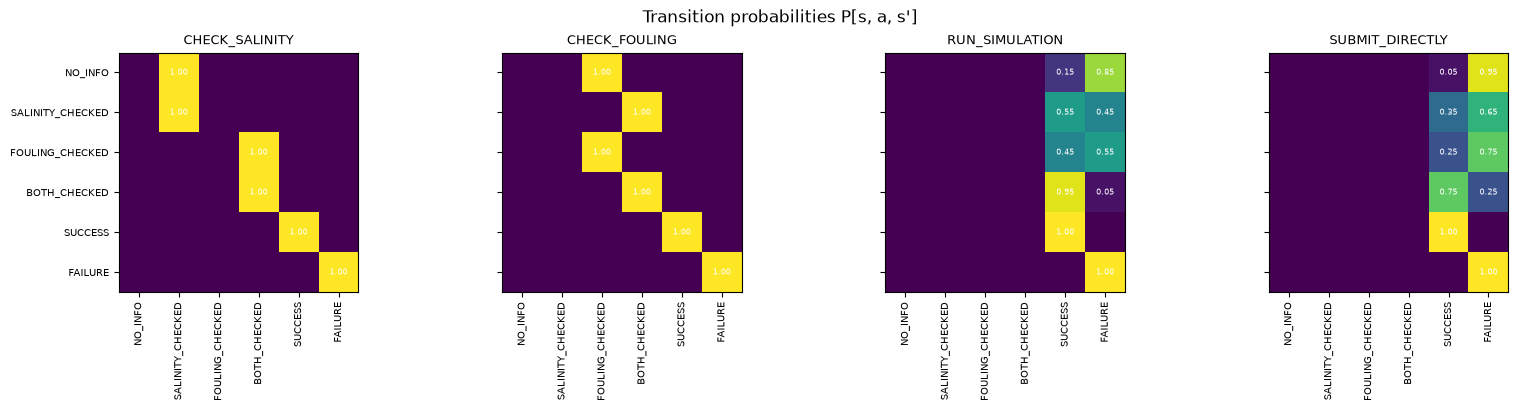

In [10]:
# Optional: a real heatmap if matplotlib happens to be installed.
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, N_ACTIONS, figsize=(16, 4), constrained_layout=True)
    names = [s.name for s in State]
    for a, ax in zip(Action, axes):
        ax.imshow(P[:, a, :], vmin=0, vmax=1, cmap="viridis")
        ax.set_title(a.name, fontsize=9)
        ax.set_xticks(range(N_STATES), names, rotation=90, fontsize=7)
        ax.set_yticks(range(N_STATES), names if a == 0 else [""] * N_STATES, fontsize=7)
        for i in range(N_STATES):
            for j in range(N_STATES):
                if P[i, a, j] > 0:
                    ax.text(j, i, f"{P[i, a, j]:.2f}", ha="center", va="center",
                            color="w", fontsize=6)
    fig.suptitle("Transition probabilities P[s, a, s']")
    plt.show()
except ImportError:
    print("matplotlib not installed - the text heatmap above covers the same ground.")
    print("to enable: pip install matplotlib")

## From MDP to MRP: fixing a policy

An MDP plus a fixed policy $\pi$ is a **Markov Reward Process** — no more
choices, just a chain that moves and pays out. This is the object policy
evaluation works on, and collapsing to it is the first step of nearly every
algorithm in the following notebooks.

Averaging the action dimension out under $\pi$ gives:

$$P_\pi[s, s'] = \sum_a \pi(a \mid s)\, P[s, a, s'], \qquad
  R_\pi[s] = \sum_a \pi(a \mid s)\, R[s, a]$$

In [11]:
def policy_matrices(pi, P, R):
    # Collapse an MDP + policy into an MRP: (P_pi [S,S], R_pi [S]).
    P_pi = np.einsum("sa,sat->st", pi, P)
    R_pi = np.einsum("sa,sa->s", pi, R)
    return P_pi, R_pi


def deterministic(action_of_state) -> np.ndarray:
    # Build a [S, A] policy matrix from a {state: action} mapping.
    pi = np.zeros((N_STATES, N_ACTIONS))
    for s in State:
        pi[s, action_of_state(s)] = 1.0
    return pi


careful_pi = deterministic(lambda s: {
    State.NO_INFO: Action.CHECK_SALINITY,
    State.SALINITY_CHECKED: Action.CHECK_FOULING,
    State.FOULING_CHECKED: Action.CHECK_SALINITY,
    State.BOTH_CHECKED: Action.RUN_SIMULATION,
}.get(s, Action.RUN_SIMULATION))

P_pi, R_pi = policy_matrices(careful_pi, P, R)

print("MRP under the 'careful' policy — P_pi[s, s']:")
print(f"{'':<18}" + "".join(f"{State(j).name[:7]:>9}" for j in State))
for i in State:
    print(f"{State(i).name:<18}" + "".join(f"{P_pi[i, j]:>9.2f}" for j in State))

print("\nR_pi[s]:")
for s in State:
    print(f"  {s.name:<18}{R_pi[s]:>7.2f}")

MRP under the 'careful' policy — P_pi[s, s']:
                    NO_INFO  SALINIT  FOULING  BOTH_CH  SUCCESS  FAILURE
NO_INFO                0.00     1.00     0.00     0.00     0.00     0.00
SALINITY_CHECKED       0.00     0.00     0.00     1.00     0.00     0.00
FOULING_CHECKED        0.00     0.00     0.00     1.00     0.00     0.00
BOTH_CHECKED           0.00     0.00     0.00     0.00     0.95     0.05
SUCCESS                0.00     0.00     0.00     0.00     1.00     0.00
FAILURE                0.00     0.00     0.00     0.00     0.00     1.00

R_pi[s]:
  NO_INFO             -0.50
  SALINITY_CHECKED    -0.50
  FOULING_CHECKED     -0.50
  BOTH_CHECKED         8.00
  SUCCESS              0.00
  FAILURE              0.00


That `P_pi` is the **transition matrix of the MRP** drawn in the diagram above:
a single 6x6 matrix, each row a probability distribution. The careful policy
walks `NO_INFO -> SALINITY_CHECKED -> BOTH_CHECKED` deterministically, then
gambles once with 95/5 odds. Notebook 02 solves this matrix directly for the
policy's exact value.

## The sampling interface

Exact methods get to read $P$ and $R$. **Model-free** methods do not — they only
get to *act and observe*. `step()` is that narrower doorway, and notebooks 03–05
use nothing else.

The distinction matters more than it looks. Everything from Monte Carlo onward
is designed for problems where you could never write down $P$, because it is
unknown or far too large to store. We happen to have $P$ here only so we can
grade those methods against the truth.

In [12]:
def step(state, action, rng) -> tuple[State, float, bool]:
    # Sample one environment step: (next_state, reward, done).
    # Inverse-CDF sampling from a single uniform draw. The obvious
    # rng.choice(..., p=probs) is ~4x slower per call, which matters once the
    # later notebooks run hundreds of thousands of episodes.
    outcomes = transitions(state, action)
    if len(outcomes) == 1:
        only = outcomes[0]
        return only.next_state, only.reward, is_terminal(only.next_state)
    u, cumulative = rng.random(), 0.0
    for prob, next_state, reward in outcomes:
        cumulative += prob
        if u < cumulative:
            return next_state, reward, is_terminal(next_state)
    last = outcomes[-1]  # float-rounding fallback
    return last.next_state, last.reward, is_terminal(last.next_state)


def rollout(policy_fn, rng, max_steps=20):
    # Run one episode; return a list of (state, action, reward) triples.
    s, traj = State.NO_INFO, []
    for _ in range(max_steps):
        a = policy_fn(s, rng)
        ns, r, done = step(s, a, rng)
        traj.append((s, a, r))
        s = ns
        if done:
            break
    return traj


def show(traj):
    total = sum(r for _, _, r in traj)
    for s, a, r in traj:
        print(f"  {State(s).name:<18} --{Action(a).name:<16}--> {r:+.1f}")
    print(f"  total (undiscounted) = {total:+.1f}")
    return total

### Two episodes, two policies

A **policy** $\pi(a \mid s)$ maps states to action choices. Below: a reckless
policy that submits immediately, and a careful one that gathers both pieces of
evidence first.

Re-run these cells a few times. The careful policy pays `-1.0` in checks up
front and *still* comes out far ahead on average — but on any single episode it
can lose, which is exactly why we need expectations rather than anecdotes.

In [13]:
def reckless(state, rng):
    return Action.SUBMIT_DIRECTLY


def careful(state, rng):
    if state == State.NO_INFO:
        return Action.CHECK_SALINITY
    if state == State.SALINITY_CHECKED:
        return Action.CHECK_FOULING
    if state == State.FOULING_CHECKED:
        return Action.CHECK_SALINITY
    return Action.RUN_SIMULATION


rng = np.random.default_rng(7)
print("reckless episode:")
show(rollout(reckless, rng))
print("\ncareful episode:")
show(rollout(careful, rng))

reckless episode:
  NO_INFO            --SUBMIT_DIRECTLY --> -10.0
  total (undiscounted) = -10.0

careful episode:
  NO_INFO            --CHECK_SALINITY  --> -0.5
  SALINITY_CHECKED   --CHECK_FOULING   --> -0.5
  BOTH_CHECKED       --RUN_SIMULATION  --> +9.0
  total (undiscounted) = +8.0


8.0

Two episodes prove nothing — that is the point. Each is one draw from a random
process, and a lucky reckless run can beat an unlucky careful one.

To compare policies we need **expectations**, which means averaging over many
episodes.

In [14]:
# Averages over many episodes tell a much steadier story than any single run.
rng = np.random.default_rng(11)
for name, pol in [("reckless", reckless), ("careful", careful)]:
    returns = [sum(r for _, _, r in rollout(pol, rng)) for _ in range(20_000)]
    print(f"{name:<10} mean return = {np.mean(returns):+.3f}   sd = {np.std(returns):.3f}")

reckless   mean return = -9.007   sd = 4.344
careful    mean return = +6.979   sd = 4.402


Careful wins by a wide margin: roughly `+7.0` against `-9.0`.

Look at the standard deviations, though — both near `4.4`, essentially tied.
That is worth understanding, because the naive guess is that the reliable policy
should also be the steady one. Neither policy is *uncertain* in the everyday
sense; each is a near-deterministic outcome with a small chance of the opposite.
Reckless fails 95% of the time, careful succeeds 95% of the time, and a
5%-vs-95% coin has exactly the same variance as a 95%-vs-5% one. The spread
comes from the gap between the two payoffs, which is about 20 either way.

Spread is not the same as quality — a lesson that returns in notebook 04, where
the *gradient estimator's* variance, not the policy's, is what we work to
reduce.

But "careful beats reckless" is not the same as "careful is optimal". Maybe one
check is enough. Maybe submitting after both checks beats simulating, since it
skips the simulator's cost. Guessing does not scale, and neither does trying
every policy by hand — with 4 actions in 4 real states there are $4^4 = 256$
deterministic policies here, and that number explodes on any real problem.

## Where this goes

| Notebook | Adds |
| --- | --- |
| **01 — this one** | states, actions, transitions, rewards, terminal states |
| **02** | Bellman expectation & optimality, value iteration, policy extraction |
| **03** | Monte Carlo policy evaluation — learning values from samples alone |
| **04** | REINFORCE, then baselines and a critic to cut its variance |
| **05** | PPO's probability ratio and clipping |

Next: **`02_bellman_value_iteration.ipynb`**, which computes the exact value of
any policy and finds the best one — no guessing.